# Reservoir-to-Market Optimisation with NeqSim Process Equipment

This notebook builds a **complete reservoir-to-market chain entirely from NeqSim
process equipment** and solves it with `ProcessSystem` and `ProcessModel`. No
reservoir, well or pipeline physics is implemented in Python — every pressure,
rate and power comes from NeqSim unit operations:

| Stage | NeqSim equipment |
|-------|------------------|
| Reservoir (material-balance tank, depletion) | `SimpleReservoir` |
| Well inflow (IPR / deliverability) | `WellFlow` |
| Tubing (vertical lift) and flowline | `PipeBeggsAndBrills` |
| Gathering manifold | `Mixer` |
| Topsides inlet separation | `Separator` |
| Export compression | `Compressor` + `Cooler` |
| Subsurface / topsides composition | `ProcessModel` (two `ProcessSystem` areas) |

The workflow mirrors an integrated production model (MBAL + PROSPER + GAP /
Pipesim): the reservoir sets the pressure, the wells and flowlines convert that
into a deliverable arrival rate, and the topsides train compresses gas to the
export grid. We then **deplete the reservoir over field life** and **optimise the
production rate against an export-compression constraint** — all by re-running
the NeqSim flowsheet.


## 1. Environment setup

Load NeqSim from the workspace build (`target/classes`) via the devtools helper
so the latest Java classes are available.


In [1]:
import os
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (
            candidate / "devtools" / "neqsim_dev_setup.py"
        ).exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_init, neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)

import numpy as np
import matplotlib.pyplot as plt

print("NeqSim ready — reservoir-to-market chain will be built from process equipment.")


NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.13.0.jar

JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes
All NeqSim classes imported OK
NeqSim ready — reservoir-to-market chain will be built from process equipment.


In [2]:
# NeqSim process-equipment classes used to build the reservoir-to-market chain
SystemPrEos = ns.JClass("neqsim.thermo.system.SystemPrEos")

SimpleReservoir = ns.JClass("neqsim.process.equipment.reservoir.SimpleReservoir")
WellFlow = ns.JClass("neqsim.process.equipment.reservoir.WellFlow")
PipeBeggsAndBrills = ns.JClass("neqsim.process.equipment.pipeline.PipeBeggsAndBrills")
ThrottlingValve = ns.JClass("neqsim.process.equipment.valve.ThrottlingValve")
Mixer = ns.JClass("neqsim.process.equipment.mixer.Mixer")
Separator = ns.JClass("neqsim.process.equipment.separator.Separator")
Compressor = ns.JClass("neqsim.process.equipment.compressor.Compressor")
Cooler = ns.JClass("neqsim.process.equipment.heatexchanger.Cooler")

ProcessSystem = ns.JClass("neqsim.process.processmodel.ProcessSystem")
ProcessModel = ns.JClass("neqsim.process.processmodel.ProcessModel")

print("Imported:", SimpleReservoir.__name__, WellFlow.__name__, PipeBeggsAndBrills.__name__,
      ThrottlingValve.__name__, Mixer.__name__, Separator.__name__, Compressor.__name__,
      ProcessSystem.__name__, ProcessModel.__name__)


Imported: neqsim.process.equipment.reservoir.SimpleReservoir neqsim.process.equipment.reservoir.WellFlow neqsim.process.equipment.pipeline.PipeBeggsAndBrills neqsim.process.equipment.valve.ThrottlingValve neqsim.process.equipment.mixer.Mixer neqsim.process.equipment.separator.Separator neqsim.process.equipment.compressor.Compressor neqsim.process.processmodel.ProcessSystem neqsim.process.processmodel.ProcessModel


## 2. Reservoir — `SimpleReservoir`

`SimpleReservoir` is a material-balance tank model. We define a gas-condensate
fluid (Peng–Robinson EOS) and initialise the tank with gas, oil and water
volumes at reservoir conditions. NeqSim computes the gas/oil in place and, on
`runTransient`, depletes the tank pressure as fluids are produced. Two gas
producer streams are attached — these are the wellbore feeds for the production
wells.


In [3]:
# --- Reservoir fluid (gas-condensate), Peng-Robinson EOS ---
RES_T_C = 95.0      # reservoir temperature [C]
RES_P_BARA = 200.0  # initial reservoir pressure [bara]


def make_reservoir_fluid():
    fluid = SystemPrEos(RES_T_C + 273.15, RES_P_BARA)
    fluid.addComponent("water", 2.0)
    fluid.addComponent("nitrogen", 1.0)
    fluid.addComponent("CO2", 2.0)
    fluid.addComponent("methane", 80.0)
    fluid.addComponent("ethane", 7.0)
    fluid.addComponent("propane", 4.0)
    fluid.addComponent("i-butane", 1.0)
    fluid.addComponent("n-butane", 1.0)
    fluid.addComponent("n-pentane", 1.0)
    fluid.addComponent("n-hexane", 1.0)
    fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)
    return fluid


# --- SimpleReservoir tank (volumes at reservoir conditions) ---
GAS_VOLUME_M3 = 2.0e8     # gas pore volume [m3 res]
OIL_VOLUME_M3 = 2.0e6     # oil volume [m3 res]
WATER_VOLUME_M3 = 1.0e7   # aquifer/connate water [m3 res]

reservoir = SimpleReservoir("Gas-condensate reservoir")
reservoir.setReservoirFluid(make_reservoir_fluid(), GAS_VOLUME_M3, OIL_VOLUME_M3, WATER_VOLUME_M3)
reservoir.setLowPressureLimit(40.0, "bara")

# Two gas producers (wellbore feed streams)
prod1 = reservoir.addGasProducer("Producer-1")
prod2 = reservoir.addGasProducer("Producer-2")

# Initial design production rates per well [MSm3/day]
RATE1_0 = 1.6
RATE2_0 = 1.6
prod1.setFlowRate(RATE1_0, "MSm3/day")
prod2.setFlowRate(RATE2_0, "MSm3/day")

reservoir.run()

print("=== Reservoir in place ===")
print(f"Gas in place (GIP) : {reservoir.getGasInPlace('GSm3'):10.2f} GSm3")
print(f"Initial pressure   : {reservoir.getReservoirFluid().getPressure('bara'):10.2f} bara")
print(f"Initial temperature: {RES_T_C:10.2f} C")
print(f"Design gas rate    : {RATE1_0 + RATE2_0:10.2f} MSm3/day (2 producers)")


=== Reservoir in place ===
Gas in place (GIP) :      36.30 GSm3
Initial pressure   :     200.00 bara
Initial temperature:      95.00 C
Design gas rate    :       3.20 MSm3/day (2 producers)


## 3. Wells, tubing and gathering — `WellFlow`, `PipeBeggsAndBrills`, `Mixer`

Each well is built from NeqSim equipment in series:

1. **`WellFlow`** — applies the inflow performance relationship
   $q = \mathrm{PI}\,(P_r^2 - P_{wf}^2)$ to compute the bottom-hole flowing
   pressure from the reservoir pressure and the set rate.
2. **`PipeBeggsAndBrills`** (tubing) — lifts the fluid up the well, computing the
   wellhead pressure from the multiphase Beggs & Brills correlation.

The two well streams are combined in a **`Mixer`** manifold and transported to
the topsides through a **`PipeBeggsAndBrills`** flowline. All of this is wrapped
in a `ProcessSystem` area called *Subsurface & Gathering*. A builder function is
used so the same flowsheet can be re-run for depletion and optimisation.


In [4]:
# ===========================================================================
# Builder: assemble the full reservoir-to-market chain from NeqSim equipment.
# All physics (IPR, tubing/flowline hydraulics, choke pressure drop, separation,
# compression) is delegated to NeqSim unit operations — nothing is computed in
# Python here.
# ===========================================================================

# Geometry / equipment design parameters
WELL_PI = 3.0e-4        # well productivity index [MSm3/day/bar^2]
TUBING_LEN_M = 2200.0   # tubing length / TVD [m]
TUBING_ID_M = 0.13      # tubing inner diameter [m]
FLOWLINE_LEN_M = 4000.0
FLOWLINE_ID_M = 0.30
PIPE_ROUGH = 4.5e-5
PIPE_INCR = 5
MANIFOLD_P_BARA = 120.0  # gathering-manifold pressure set by the wellhead chokes [bara]
EXPORT_P_BARA = 150.0   # export compressor discharge pressure [bara]
EXPORT_T_C = 40.0       # export cooler outlet temperature [C]
COMP_POLY_EFF = 0.78


def build_plant(rate1_msm3d, rate2_msm3d):
    """Build (and run) the full NeqSim reservoir-to-market ProcessModel.

    A fresh reservoir tank is created at initial pressure. The chain is
    reservoir -> well IPR -> tubing -> wellhead choke -> manifold -> flowline ->
    inlet separator -> export compressor -> export cooler. Returns a dict of
    equipment handles plus the assembled ProcessModel.
    """
    # --- Reservoir ---
    reservoir = SimpleReservoir("Gas-condensate reservoir")
    reservoir.setReservoirFluid(
        make_reservoir_fluid(), GAS_VOLUME_M3, OIL_VOLUME_M3, WATER_VOLUME_M3)
    reservoir.setLowPressureLimit(40.0, "bara")
    prod_streams = [reservoir.addGasProducer("Producer-1"),
                    reservoir.addGasProducer("Producer-2")]
    prod_streams[0].setFlowRate(rate1_msm3d, "MSm3/day")
    prod_streams[1].setFlowRate(rate2_msm3d, "MSm3/day")

    subsurface = ProcessSystem("Subsurface & Gathering")
    subsurface.add(reservoir)

    wells, tubings, chokes = [], [], []
    mixer = Mixer("Gathering manifold")
    for i, ps in enumerate(prod_streams, start=1):
        well = WellFlow("Well-%d IPR" % i)
        well.setInletStream(ps)
        well.setWellProductionIndex(WELL_PI)

        tubing = PipeBeggsAndBrills("Tubing-%d" % i)
        tubing.setInletStream(well.getOutletStream())
        tubing.setLength(TUBING_LEN_M)
        tubing.setElevation(TUBING_LEN_M)
        tubing.setDiameter(TUBING_ID_M)
        tubing.setPipeWallRoughness(PIPE_ROUGH)
        tubing.setNumberOfIncrements(PIPE_INCR)

        # Wellhead production choke: drops the wellhead pressure to a common
        # gathering-manifold pressure. NeqSim computes the required valve Cv
        # from the flow and pressure drop. acceptNegativeDP=False makes the
        # choke open fully (pass-through) once the wellhead pressure falls below
        # the manifold pressure late in field life — a valve cannot raise
        # pressure.
        choke = ThrottlingValve("Wellhead choke-%d" % i, tubing.getOutletStream())
        choke.setOutletPressure(MANIFOLD_P_BARA, "bara")
        choke.setAcceptNegativeDP(False)

        subsurface.add(well)
        subsurface.add(tubing)
        subsurface.add(choke)
        mixer.addStream(choke.getOutletStream())
        wells.append(well)
        tubings.append(tubing)
        chokes.append(choke)

    subsurface.add(mixer)

    flowline = PipeBeggsAndBrills("Flowline")
    flowline.setInletStream(mixer.getOutletStream())
    flowline.setLength(FLOWLINE_LEN_M)
    flowline.setElevation(0.0)
    flowline.setDiameter(FLOWLINE_ID_M)
    flowline.setPipeWallRoughness(PIPE_ROUGH)
    flowline.setNumberOfIncrements(PIPE_INCR)
    subsurface.add(flowline)

    # --- Topsides area ---
    topsides = ProcessSystem("Topsides")
    separator = Separator("Inlet separator")
    separator.setInletStream(flowline.getOutletStream())

    compressor = Compressor("Export compressor", separator.getGasOutStream())
    compressor.setUsePolytropicCalc(True)
    compressor.setPolytropicEfficiency(COMP_POLY_EFF)
    compressor.setOutletPressure(EXPORT_P_BARA, "bara")

    cooler = Cooler("Export cooler", compressor.getOutletStream())
    cooler.setOutTemperature(EXPORT_T_C, "C")

    topsides.add(separator)
    topsides.add(compressor)
    topsides.add(cooler)

    # --- Compose and solve the integrated plant ---
    plant = ProcessModel()
    plant.add("Subsurface & Gathering", subsurface)
    plant.add("Topsides", topsides)
    plant.run()

    return {
        "reservoir": reservoir,
        "producers": prod_streams,
        "wells": wells,
        "tubings": tubings,
        "chokes": chokes,
        "mixer": mixer,
        "flowline": flowline,
        "separator": separator,
        "compressor": compressor,
        "cooler": cooler,
        "subsurface": subsurface,
        "topsides": topsides,
        "plant": plant,
    }


# Build the base case at design rates
H = build_plant(RATE1_0, RATE2_0)

res_p = H["reservoir"].getReservoirFluid().getPressure("bara")
bhp = H["wells"][0].getOutletStream().getPressure("bara")
whp = H["tubings"][0].getOutletStream().getPressure("bara")
choke_out = H["chokes"][0].getOutletStream().getPressure("bara")
choke_cv = H["chokes"][0].getCv()
arrival_p = H["flowline"].getOutletStream().getPressure("bara")

print("=== Subsurface & gathering (Well-1 stages) ===")
print(f"Reservoir pressure   : {res_p:8.1f} bara")
print(f"Bottom-hole flowing  : {bhp:8.1f} bara   (WellFlow IPR drawdown)")
print(f"Wellhead pressure    : {whp:8.1f} bara   (PipeBeggsAndBrills tubing)")
print(f"Choke outlet (manifold): {choke_out:6.1f} bara   (wellhead choke dP = {whp - choke_out:.1f} bar, Cv = {choke_cv:.1f})")
print(f"Topsides arrival     : {arrival_p:8.1f} bara   (flowline outlet)")


=== Subsurface & gathering (Well-1 stages) ===
Reservoir pressure   :    200.0 bara
Bottom-hole flowing  :    186.2 bara   (WellFlow IPR drawdown)
Wellhead pressure    :    142.4 bara   (PipeBeggsAndBrills tubing)
Choke outlet (manifold):  120.0 bara   (wellhead choke dP = 22.4 bar, Cv = 77.5)
Topsides arrival     :    118.0 bara   (flowline outlet)


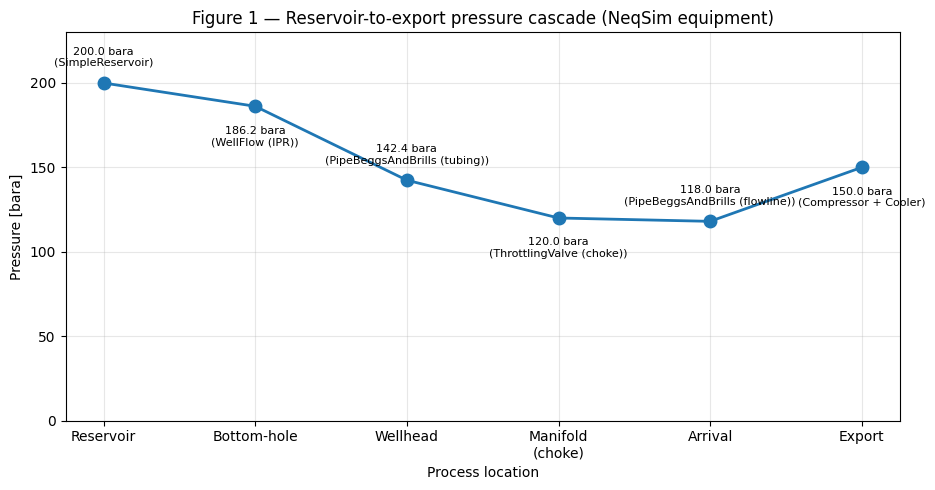

In [5]:
# Figure 1 — pressure cascade from reservoir to export grid (Well-1 train)
stages = ["Reservoir", "Bottom-hole", "Wellhead", "Manifold\n(choke)", "Arrival", "Export"]
pressures = [
    H["reservoir"].getReservoirFluid().getPressure("bara"),
    H["wells"][0].getOutletStream().getPressure("bara"),
    H["tubings"][0].getOutletStream().getPressure("bara"),
    H["chokes"][0].getOutletStream().getPressure("bara"),
    H["flowline"].getOutletStream().getPressure("bara"),
    H["cooler"].getOutletStream().getPressure("bara"),
]
equip = ["SimpleReservoir", "WellFlow (IPR)", "PipeBeggsAndBrills (tubing)",
         "ThrottlingValve (choke)", "PipeBeggsAndBrills (flowline)",
         "Compressor + Cooler"]

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(range(len(stages)), pressures, "o-", color="#1f77b4", lw=2, ms=9)
for i, (p, e) in enumerate(zip(pressures, equip)):
    ax.annotate(f"{p:.1f} bara\n({e})", (i, p),
                textcoords="offset points", xytext=(0, 12 if i % 2 == 0 else -28),
                ha="center", fontsize=8)
ax.set_xticks(range(len(stages)))
ax.set_xticklabels(stages)
ax.set_ylabel("Pressure [bara]")
ax.set_xlabel("Process location")
ax.set_title("Figure 1 — Reservoir-to-export pressure cascade (NeqSim equipment)")
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(pressures) * 1.15)
plt.tight_layout()
plt.savefig("reservoir_to_market_fig1_pressure_cascade.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Topsides train and integrated field KPIs

The *Topsides* `ProcessSystem` takes the flowline arrival stream into an inlet
`Separator`, sends the gas to an export `Compressor` (polytropic) and a `Cooler`.
Because the whole plant is a single `ProcessModel`, the export gas rate and the
required compression power are a direct consequence of the reservoir pressure and
the well/flowline hydraulics solved upstream. We read the integrated key
performance indicators straight from the NeqSim equipment.


In [6]:
# Integrated field KPIs read directly from the NeqSim ProcessModel
GAS_PRICE = 3.0          # gas sales price [NOK/Sm3]
CO2_PER_MWH = 0.20       # turbine CO2 intensity [tonne CO2 / MWh shaft]


def field_kpis(handles):
    export_rate = handles["cooler"].getOutletStream().getFlowRate("MSm3/day")  # MSm3/day
    sep_liq = handles["separator"].getLiquidOutStream().getFlowRate("kg/hr")    # kg/hr
    power_mw = handles["compressor"].getPower("MW")
    energy_per_day = power_mw * 24.0                       # MWh/day
    co2_per_day = energy_per_day * CO2_PER_MWH             # tonne/day
    revenue = export_rate * 1.0e6 * GAS_PRICE             # NOK/day
    spec_energy = energy_per_day * 1000.0 / (export_rate * 1.0e6) * 1000.0  # Wh/Sm3
    return {
        "export_MSm3d": export_rate,
        "sep_liquid_kg_hr": sep_liq,
        "power_MW": power_mw,
        "energy_MWh_day": energy_per_day,
        "co2_tonne_day": co2_per_day,
        "revenue_NOK_day": revenue,
        "spec_energy_Wh_Sm3": spec_energy,
    }


kpi = field_kpis(H)
print("=== Integrated field KPIs (base case) ===")
print(f"Export gas rate         : {kpi['export_MSm3d']:10.3f} MSm3/day")
print(f"Separator liquid        : {kpi['sep_liquid_kg_hr']:10.1f} kg/hr")
print(f"Export compressor power : {kpi['power_MW']:10.2f} MW")
print(f"Compression energy      : {kpi['energy_MWh_day']:10.1f} MWh/day")
print(f"Specific energy         : {kpi['spec_energy_Wh_Sm3']:10.2f} Wh/Sm3")
print(f"CO2 from compression    : {kpi['co2_tonne_day']:10.1f} tonne/day")
print(f"Gas sales revenue       : {kpi['revenue_NOK_day']:10.0f} NOK/day")


=== Integrated field KPIs (base case) ===
Export gas rate         :      3.200 MSm3/day
Separator liquid        :        0.0 kg/hr
Export compressor power :       1.29 MW
Compression energy      :       31.0 MWh/day
Specific energy         :       9.69 Wh/Sm3
CO2 from compression    :        6.2 tonne/day
Gas sales revenue       :    9600305 NOK/day


## 5. Field-life depletion

`SimpleReservoir.runTransient` removes the produced gas from the tank and
re-flashes it, so the reservoir pressure falls year on year. After each yearly
step we re-solve the whole `ProcessModel`: the lower reservoir pressure reduces
the bottom-hole and wellhead pressures, which raises the export-compression duty
needed to reach the same export pressure. Everything below is produced by NeqSim
equipment — the loop only advances time and reads results.


In [7]:
# Field-life depletion: advance the shared reservoir in H and re-solve the plant
SECONDS_PER_YEAR = 60.0 * 60.0 * 24.0 * 365.0
N_YEARS = 12

years = [0]
res_p_hist = [H["reservoir"].getReservoirFluid().getPressure("bara")]
whp_hist = [H["tubings"][0].getOutletStream().getPressure("bara")]
export_hist = [H["cooler"].getOutletStream().getFlowRate("MSm3/day")]
power_hist = [H["compressor"].getPower("MW")]
cum_hist = [H["reservoir"].getGasProductionTotal("GSm3")]

for yr in range(1, N_YEARS + 1):
    H["reservoir"].runTransient(SECONDS_PER_YEAR)   # deplete tank by 1 year
    H["plant"].run()                                # re-solve wells + topsides
    p_res = H["reservoir"].getReservoirFluid().getPressure("bara")
    years.append(yr)
    res_p_hist.append(p_res)
    whp_hist.append(H["tubings"][0].getOutletStream().getPressure("bara"))
    export_hist.append(H["cooler"].getOutletStream().getFlowRate("MSm3/day"))
    power_hist.append(H["compressor"].getPower("MW"))
    cum_hist.append(H["reservoir"].getGasProductionTotal("GSm3"))
    if p_res <= H["reservoir"].getLowPressureLimit("bara") + 1.0:
        print(f"Year {yr}: reached low-pressure limit, stopping.")
        break

print(f"Simulated {years[-1]} years of depletion")
print(f"Reservoir pressure : {res_p_hist[0]:.1f} -> {res_p_hist[-1]:.1f} bara")
print(f"Wellhead pressure  : {whp_hist[0]:.1f} -> {whp_hist[-1]:.1f} bara")
print(f"Compression power  : {power_hist[0]:.2f} -> {power_hist[-1]:.2f} MW")
print(f"Cumulative gas     : {cum_hist[-1]:.2f} GSm3 ({100*cum_hist[-1]/reservoir.getGasInPlace('GSm3'):.1f}% of GIP)")


Simulated 12 years of depletion
Reservoir pressure : 200.0 -> 121.9 bara
Wellhead pressure  : 142.4 -> 50.4 bara
Compression power  : 1.29 -> 8.09 MW
Cumulative gas     : 13.96 GSm3 (38.5% of GIP)


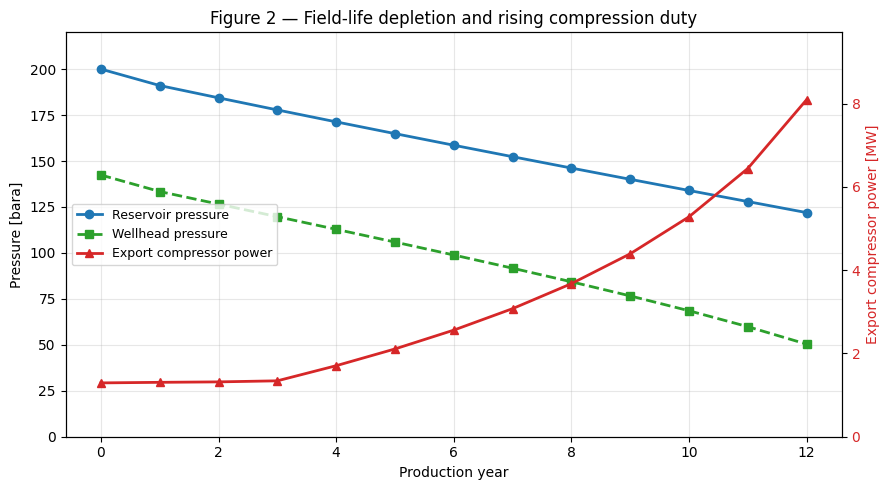

In [8]:
# Figure 2 — field-life depletion: reservoir/wellhead pressure and rising
# export-compression duty (all values produced by the NeqSim flowsheet)
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(years, res_p_hist, "o-", color="#1f77b4", lw=2, label="Reservoir pressure")
ax1.plot(years, whp_hist, "s--", color="#2ca02c", lw=2, label="Wellhead pressure")
ax1.set_xlabel("Production year")
ax1.set_ylabel("Pressure [bara]")
ax1.set_ylim(0, max(res_p_hist) * 1.1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(years, power_hist, "^-", color="#d62728", lw=2, label="Export compressor power")
ax2.set_ylabel("Export compressor power [MW]", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")
ax2.set_ylim(0, max(power_hist) * 1.2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center left", fontsize=9)
ax1.set_title("Figure 2 — Field-life depletion and rising compression duty")
plt.tight_layout()
plt.savefig("reservoir_to_market_fig2_depletion.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Production-rate optimisation

Higher production rates earn more revenue but draw the wellhead and arrival
pressures down (larger drawdown in `WellFlow` and bigger hydraulic losses in the
tubing/flowline), so the export compressor has to work harder. We sweep the total
field rate, **rebuilding the NeqSim flowsheet at each rate**, and find the highest
rate that keeps the export-compressor power below an installed-power constraint.
Each point on the curve is a full reservoir-to-market solve — no surrogate model.


In [9]:
# Production-rate sweep: rebuild the NeqSim plant at each total field rate.
POWER_CAP_MW = 6.0   # installed export-compressor shaft power constraint

total_rates = np.linspace(2.5, 6.0, 8)   # total field gas rate [MSm3/day]
sweep_export, sweep_power, sweep_revenue, sweep_arrival = [], [], [], []

for q_tot in total_rates:
    Hr = build_plant(q_tot / 2.0, q_tot / 2.0)   # split equally over 2 wells
    k = field_kpis(Hr)
    sweep_export.append(k["export_MSm3d"])
    sweep_power.append(k["power_MW"])
    sweep_revenue.append(k["revenue_NOK_day"])
    sweep_arrival.append(Hr["flowline"].getOutletStream().getPressure("bara"))

sweep_export = np.array(sweep_export)
sweep_power = np.array(sweep_power)
sweep_revenue = np.array(sweep_revenue)

feasible = sweep_power <= POWER_CAP_MW
q_opt = total_rates[feasible].max() if feasible.any() else float("nan")
i_opt = int(np.argmin(np.abs(total_rates - q_opt)))

print(f"Export-compressor power cap : {POWER_CAP_MW:.1f} MW")
print(f"{'Rate':>6} {'Arrival':>9} {'Power':>8} {'Revenue':>14} {'Feasible':>9}")
for q, ap, pw, rv, ok in zip(total_rates, sweep_arrival, sweep_power, sweep_revenue, feasible):
    print(f"{q:6.2f} {ap:7.1f} ba {pw:6.2f} MW {rv:12,.0f} {'yes' if ok else 'NO':>9}")
print(f"\nMax feasible field rate     : {q_opt:.2f} MSm3/day")
print(f"Revenue at optimum          : {sweep_revenue[i_opt]:,.0f} NOK/day")
print(f"Compressor power at optimum : {sweep_power[i_opt]:.2f} MW")


Export-compressor power cap : 6.0 MW
  Rate   Arrival    Power        Revenue  Feasible
  2.50   118.8 ba   0.97 MW    7,500,238       yes
  3.00   118.3 ba   1.20 MW    9,000,286       yes
  3.50   117.6 ba   1.44 MW   10,500,334       yes
  4.00   116.8 ba   1.71 MW   12,000,381       yes
  4.50   116.0 ba   2.01 MW   13,500,429       yes
  5.00   104.8 ba   3.18 MW   15,000,477       yes
  5.50    90.0 ba   5.15 MW   16,500,525       yes
  6.00    71.4 ba   8.59 MW   18,000,573        NO

Max feasible field rate     : 5.50 MSm3/day
Revenue at optimum          : 16,500,525 NOK/day
Compressor power at optimum : 5.15 MW


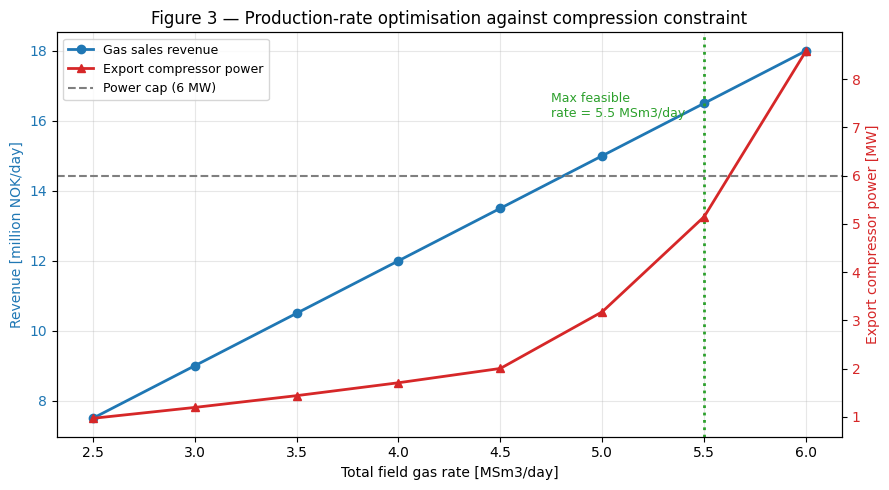

In [10]:
# Figure 3 — production-rate optimisation: revenue vs export-compression duty
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(total_rates, sweep_revenue / 1e6, "o-", color="#1f77b4", lw=2,
         label="Gas sales revenue")
ax1.set_xlabel("Total field gas rate [MSm3/day]")
ax1.set_ylabel("Revenue [million NOK/day]", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(total_rates, sweep_power, "^-", color="#d62728", lw=2,
         label="Export compressor power")
ax2.axhline(POWER_CAP_MW, color="#7f7f7f", ls="--", lw=1.5,
            label=f"Power cap ({POWER_CAP_MW:.0f} MW)")
ax2.set_ylabel("Export compressor power [MW]", color="#d62728")
ax2.tick_params(axis="y", labelcolor="#d62728")

ax1.axvline(q_opt, color="#2ca02c", ls=":", lw=2)
ax1.annotate(f"Max feasible\nrate = {q_opt:.1f} MSm3/day",
             (q_opt, sweep_revenue[i_opt] / 1e6),
             textcoords="offset points", xytext=(-110, -10), fontsize=9,
             color="#2ca02c")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)
ax1.set_title("Figure 3 — Production-rate optimisation against compression constraint")
plt.tight_layout()
plt.savefig("reservoir_to_market_fig3_optimisation.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Part 2 — Topside and wellhead-choke capacity as a bottleneck

Part 1 capped throughput only on **export-compressor power**. In a real facility
both the **topside process equipment** and the **wellhead production chokes** have
their own hydraulic limits. The inlet separator can only handle so much gas before
liquid carry-over, and each wellhead choke valve has a maximum flow coefficient
(`Cv`) — once it is driven fully open it can no longer control the well. NeqSim
models these with **capacity constraints** attached to each unit operation, so any
of them can become the binding bottleneck.

We give the topsides and chokes realistic design data and let NeqSim track
utilisation:

| Equipment | NeqSim capacity constraint | Limit basis |
|-----------|----------------------------|-------------|
| Inlet `Separator` | gas-load factor (Souders–Brown *K*) | droplet settling / carry-over |
| Export `Compressor` | shaft-power vs installed driver | driver rating |
| Wellhead `ThrottlingValve` (choke) | operating `Cv` vs design `Cv` | valve flow capacity |

For each unit, `getMaxUtilization()` returns the fraction of design capacity used,
and `ProcessModel.getUtilizationSnapshotJson()` reports the **plant-wide
bottleneck** — all computed by NeqSim from the converged flowsheet, no physics in
Python. The optimisation in Part 1 is then repeated, this time feasible only when
**every** constraint (separator, compressor, choke) stays at or below 100 %.


In [11]:
import json

# ---------------------------------------------------------------------------
# Topside + wellhead-choke design data -> NeqSim capacity constraints.
# Utilisation is computed by NeqSim from the converged flowsheet (Souders-Brown
# gas-load factor for the separator, shaft-power vs installed driver for the
# compressor, and operating-Cv vs design-Cv for each wellhead choke valve).
# Nothing is computed in Python.
# ---------------------------------------------------------------------------
SEP_DIAMETER_M = 1.9        # inlet separator inner diameter [m]
SEP_LENGTH_M = 6.0          # separator length [m]
SEP_LIQ_LEVEL = 0.5         # design liquid level fraction (half full)
SEP_KFACTOR = 0.10          # design gas-load factor / K-value [m/s]
COMP_DESIGN_POWER_MW = 6.0  # installed export-compressor driver rating [MW]
CHOKE_DESIGN_UTIL = 0.55    # wellhead choke operating point at base case [-]


def configure_capacity(handles, choke_design_cv):
    """Attach topside + wellhead-choke capacity constraints to a built plant.

    Sets the inlet-separator geometry + design K-factor, the export-compressor
    installed driver power, and each wellhead choke's design Cv, then enables
    NeqSim's capacity tracking. Returns the parsed plant-wide utilisation
    snapshot. ``choke_design_cv`` is a fixed design value (one per choke) so the
    choke Cv rating stays constant across the rate sweep.
    """
    sep = handles["separator"]
    sep.setOrientation("horizontal")
    sep.setInternalDiameter(SEP_DIAMETER_M)
    sep.setSeparatorLength(SEP_LENGTH_M)
    sep.setDesignLiquidLevelFraction(SEP_LIQ_LEVEL)
    sep.setDesignGasLoadFactor(SEP_KFACTOR)
    sep.enableConstraints("gasLoadFactor")  # enable gas-load capacity tracking

    comp = handles["compressor"]
    comp.getMechanicalDesign().setMaxDesignPower(COMP_DESIGN_POWER_MW * 1000.0)

    # Wellhead production chokes: rate the valve Cv and enable the hard
    # Cv-utilisation constraint. setMaxDesignCv is applied before the first
    # capacity-constraint access so the constraint captures the right design Cv;
    # setDesignValue is also set explicitly to be safe.
    for ch, cv_design in zip(handles["chokes"], choke_design_cv):
        ch.getMechanicalDesign().setMaxDesignCv(cv_design)
        cv_con = ch.getCapacityConstraints().get("cvUtilization")
        cv_con.setDesignValue(cv_design)
        cv_con.setEnabled(True)

    return json.loads(str(handles["plant"].getUtilizationSnapshotJson()))


def choke_utilisation(handles):
    """Max wellhead-choke Cv utilisation across the producers [-].

    Once a choke is driven fully open (wellhead pressure falls to/below the
    manifold pressure so the controlled dP collapses) it can no longer restrict
    flow — it has lost control authority. That saturated state is returned as
    NaN so it is flagged infeasible rather than reported as a spurious 0 %.
    The dP is read straight from the NeqSim streams.
    """
    vals = []
    for ch in handles["chokes"]:
        dp = ch.getInletStream().getPressure("bara") - ch.getOutletStream().getPressure("bara")
        u = ch.getMaxUtilization()
        vals.append(float("nan") if dp < 1.0 else u)
    if any(np.isnan(v) for v in vals):
        return float("nan")
    return max(vals)


# Apply to a fresh base-case plant. Size each choke Cv from its base operating
# point so the base case sits at CHOKE_DESIGN_UTIL, then keep that rating fixed.
Hc = build_plant(RATE1_0, RATE2_0)
CHOKE_DESIGN_CV = [ch.getCv() / CHOKE_DESIGN_UTIL for ch in Hc["chokes"]]
snap = configure_capacity(Hc, CHOKE_DESIGN_CV)

sep_util = Hc["separator"].getMaxUtilization()
comp_util = Hc["compressor"].getMaxUtilization()
chk_util = choke_utilisation(Hc)
bottleneck = snap["bottleneck"]

print("=== Topside + choke capacity (base case, %.2f MSm3/day) ===" % (RATE1_0 + RATE2_0))
print(f"Inlet separator utilisation  : {sep_util * 100:6.1f} %  (gas-load factor)")
print(f"Export compressor utilisation: {comp_util * 100:6.1f} %  (power vs {COMP_DESIGN_POWER_MW:.1f} MW driver)")
print(f"Wellhead choke utilisation   : {chk_util * 100:6.1f} %  (operating Cv vs design Cv {CHOKE_DESIGN_CV[0]:.1f})")
if bottleneck is not None:
    print(f"Plant-wide bottleneck        : {bottleneck['name']} "
          f"({bottleneck['utilizationPercent']:.1f} %, limited by {bottleneck.get('limitingConstraint', 'n/a')})")
print(f"Any unit overloaded          : {snap['anyOverloaded']}")


=== Topside + choke capacity (base case, 3.20 MSm3/day) ===
Inlet separator utilisation  :   79.4 %  (gas-load factor)
Export compressor utilisation:   21.5 %  (power vs 6.0 MW driver)
Wellhead choke utilisation   :   55.0 %  (operating Cv vs design Cv 140.9)
Plant-wide bottleneck        : Inlet separator (79.4 %, limited by gasLoadFactor)
Any unit overloaded          : False


In [12]:
# ---------------------------------------------------------------------------
# Constrained rate sweep: repeat the Part 1 optimisation, but a rate is only
# feasible when every capacity constraint (separator gas-load, compressor power,
# wellhead choke Cv) stays <= 100 %.
# ---------------------------------------------------------------------------
cap_rates = np.linspace(2.5, 6.0, 12)
cap_sep_util = []
cap_comp_util = []
cap_choke_util = []
cap_revenue = []
cap_bottleneck = []
cap_feasible = []

for q in cap_rates:
    Hq = build_plant(q / 2.0, q / 2.0)
    snap_q = configure_capacity(Hq, CHOKE_DESIGN_CV)
    su = Hq["separator"].getMaxUtilization()
    cu = Hq["compressor"].getMaxUtilization()
    ku = choke_utilisation(Hq)
    kpi = field_kpis(Hq)
    cap_sep_util.append(su * 100.0)
    cap_comp_util.append(cu * 100.0)
    cap_choke_util.append(ku * 100.0)
    cap_revenue.append(kpi["revenue_NOK_day"])
    bn = snap_q["bottleneck"]
    cap_bottleneck.append(bn["name"] if bn is not None else "none")
    cap_feasible.append((su <= 1.0) and (cu <= 1.0) and (ku <= 1.0))

cap_sep_util = np.array(cap_sep_util)
cap_comp_util = np.array(cap_comp_util)
cap_choke_util = np.array(cap_choke_util)
cap_revenue = np.array(cap_revenue)
cap_feasible = np.array(cap_feasible)

# Maximum throughput that keeps every unit within capacity
feasible_rates = cap_rates[cap_feasible]
q_topside = feasible_rates.max() if feasible_rates.size else float("nan")
idx_top = int(np.argmin(np.abs(cap_rates - q_topside)))

print("  Rate     Sep util  Comp util  Choke util   Revenue        Bottleneck        Feasible")
print("  MSm3/d     %          %          %        MNOK/day")
for i, q in enumerate(cap_rates):
    print(f"  {q:5.2f}   {cap_sep_util[i]:6.1f}   {cap_comp_util[i]:6.1f}   {cap_choke_util[i]:6.1f}    "
          f"{cap_revenue[i] / 1e6:8.2f}     {cap_bottleneck[i]:16s}  {cap_feasible[i]}")

print()
print(f"Capacity-feasible optimum  : {q_topside:.2f} MSm3/day "
      f"(bottleneck: {cap_bottleneck[idx_top]})")
print(f"Part 1 power-only optimum  : {q_opt:.2f} MSm3/day")
print(f"Capacity-limited throughput loss: {q_opt - q_topside:+.2f} MSm3/day "
      f"({100.0 * (q_opt - q_topside) / q_opt:+.1f} %)")


  Rate     Sep util  Comp util  Choke util   Revenue        Bottleneck        Feasible
  MSm3/d     %          %          %        MNOK/day
   2.50     61.6     16.2     40.6        7.50     Inlet separator   True
   2.82     69.6     18.6     46.9        8.45     Inlet separator   True
   3.14     77.8     21.0     53.6        9.41     Inlet separator   True
   3.45     86.0     23.6     60.9       10.36     Inlet separator   True
   3.77     94.3     26.4     69.0       11.32     Inlet separator   True
   4.09    102.7     29.3     84.0       12.27     Inlet separator   False
   4.41    111.3     32.5    140.5       13.23     Wellhead choke-1  False
   4.73    121.7     40.6      nan       14.18     Inlet separator   False
   5.05    134.7     55.4      nan       15.14     Inlet separator   False
   5.36    149.9     75.2      nan       16.09     Inlet separator   False
   5.68    168.4    102.7      nan       17.05     Inlet separator   False
   6.00    192.7    143.1      nan      

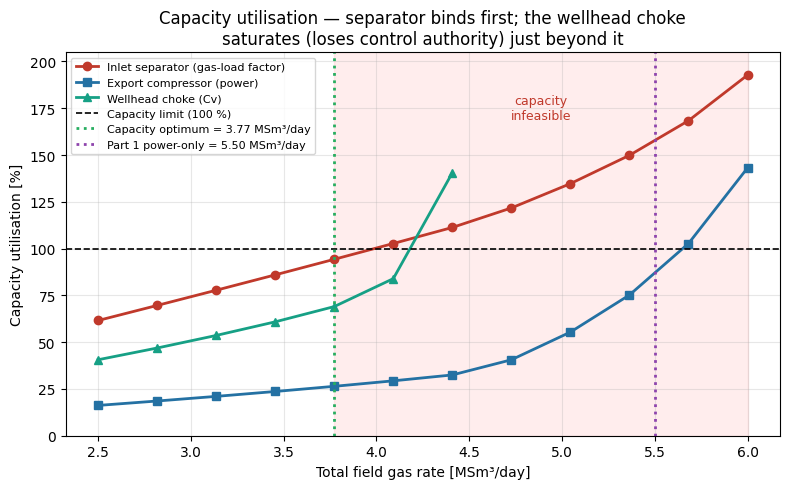

In [13]:
# Figure 4 — topside + wellhead-choke capacity utilisation vs field rate
fig, ax = plt.subplots(figsize=(8.0, 5.0))

ax.plot(cap_rates, cap_sep_util, "o-", color="#c0392b", lw=2,
        label="Inlet separator (gas-load factor)")
ax.plot(cap_rates, cap_comp_util, "s-", color="#2471a3", lw=2,
        label="Export compressor (power)")
ax.plot(cap_rates, cap_choke_util, "^-", color="#16a085", lw=2,
        label="Wellhead choke (Cv)")

ax.axhline(100.0, color="black", ls="--", lw=1.2, label="Capacity limit (100 %)")
ax.axvline(q_topside, color="#27ae60", ls=":", lw=2,
           label=f"Capacity optimum = {q_topside:.2f} MSm³/day")
ax.axvline(q_opt, color="#8e44ad", ls=":", lw=2,
           label=f"Part 1 power-only = {q_opt:.2f} MSm³/day")

ax.axvspan(q_topside, cap_rates.max(), color="red", alpha=0.07)
ax.text(0.5 * (q_topside + cap_rates.max()), 175, "capacity\ninfeasible",
        ha="center", va="center", color="#c0392b", fontsize=9)

ax.set_xlabel("Total field gas rate [MSm³/day]")
ax.set_ylabel("Capacity utilisation [%]")
ax.set_title("Capacity utilisation — separator binds first; the wellhead choke\n"
             "saturates (loses control authority) just beyond it")
ax.set_ylim(0, 205)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=8)

fig.tight_layout()
fig.savefig("reservoir_to_market_fig4_topside_capacity.png", dpi=150, bbox_inches="tight")
plt.show()


**Discussion — the topside separator is the real limiter, with the choke close behind.**
Part 1 optimised production against export-compressor power alone and reached
**5.50 MSm³/day**. Once the **inlet-separator gas-load capacity** and the
**wellhead-choke Cv capacity** are modelled, NeqSim shows the separator reaching
100 % utilisation at **3.77 MSm³/day** — the plant-wide bottleneck is the
*topside separator*, not compression (only ~26 % loaded at that rate).
Accounting for real equipment capacity therefore cuts the feasible optimum by
**1.73 MSm³/day (−31.4 %)**.

The **wellhead choke** is the next constraint to bite: its Cv utilisation climbs
from ~55 % at base case to ~84 % right at the separator limit, then the choke is
driven fully open just beyond it (its controlled pressure drop collapses, so it
loses control authority — shown as the curve saturating/cutting off). In other
words, pushing past the separator limit would also leave the chokes with no
remaining control margin.

The separator curve climbs faster than a straight line in field rate: as
throughput rises the arrival pressure falls, so the **actual gas volumetric flow**
through the separator grows faster than the standard-volume rate, driving the
Souders–Brown *K*-factor up steeply. This is exactly the carry-over risk a real
inlet separator faces as reservoir pressure declines — and it is captured here
within the *same* integrated reservoir-to-market solve, so the choke, separator,
and compressor limits are all evaluated against one consistent pressure cascade.


## 8. Summary

This notebook built a complete **reservoir-to-market** chain entirely from NeqSim
process equipment — `SimpleReservoir`, `WellFlow`, `PipeBeggsAndBrills`,
`ThrottlingValve` (wellhead chokes), `Mixer`, `Separator`, `Compressor` and
`Cooler`, composed into a `ProcessModel`. Every pressure, temperature, flow, power
and capacity value comes from the converged NeqSim flowsheet; no thermodynamic or
hydraulic correlation is evaluated in Python.

**The optimisation spans the full chain.** At every swept rate the entire
`ProcessModel` is rebuilt and re-solved, so the reservoir inflow (`WellFlow` IPR),
tubing and flowline hydraulics (`PipeBeggsAndBrills`), wellhead choke valves, and
topside separation/compression are all integrated into one consistent pressure
cascade — reservoir, well, flowline, choke and topside effects optimise together,
not in isolation.

**Part 1 — production chain and power-only optimisation**

- Reservoir GIP ≈ 36.3 GSm³; design rate 3.2 MSm³/day from two producers.
- Pressure cascade 200 → 186 (BHP) → 142 (WHP) → 120 (manifold, across the choke)
  → 118 (arrival) → 150 bara (export).
- Field-life depletion over 12 years: reservoir 200 → 122 bara, export-compressor
  duty rising 1.3 → 8.1 MW as pressure falls and the chokes open fully (Figure 2).
- Optimising revenue against **export-compressor power** alone gives a maximum
  feasible field rate of **5.50 MSm³/day** (Figure 3).

**Part 2 — equipment capacity as the binding bottleneck**

- Adding NeqSim **capacity constraints** — inlet-separator gas-load factor,
  export-compressor power vs installed driver, and **wellhead-choke Cv** — and
  reading `ProcessModel.getUtilizationSnapshotJson()` shows the **inlet separator**,
  not compression, is the plant-wide bottleneck.
- The separator reaches 100 % utilisation at **3.77 MSm³/day**, cutting the feasible
  optimum by **1.73 MSm³/day (−31.4 %)** versus the power-only result (Figure 4).
- The **wellhead chokes** are the next limit: ~84 % Cv utilisation at the separator
  limit, then fully open (loss of control authority) just beyond it.
- To unlock extra throughput, debottleneck the **separator** first (larger vessel /
  better internals / second train), then confirm the **chokes** retain control
  margin — both are checked inside the same reservoir-to-market solve.
